In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


In [12]:
# Load preprocessed feature dataset
df = pd.read_csv("features.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (3352, 62)


,accx_mean,accx_median,accx_std,accx_var,accx_min,accx_max,accx_skew,accx_kurtosis,accx_zcr,accx_energy,...,mag_kurtosis,mag_zcr,mag_energy,mag_sma,mag_ptp,mag_spectral_centroid,mag_spectral_entropy,mag_dominant_freq,ActivityLabel,UserID
0,2.363516,2.37,0.083474,0.006968,2.03,2.53,-0.445747,1.542949,0.0,715.9193,...,-0.128470,0.0,12977.9891,10.069198,0.211495,0.000045,0.000210,0.0,Standing,35
1,2.434922,2.37,0.151059,0.022819,2.22,2.87,1.253609,0.953728,0.0,761.7901,...,2.299169,0.0,12970.1968,10.066142,0.359494,0.000068,0.000280,0.0,Standing,35
2,2.556328,2.60,0.148858,0.022159,2.22,2.87,-0.226358,-0.538863,0.0,839.2703,...,4.162439,0.0,12986.4292,10.072458,0.359494,0.000057,0.000241,0.0,Standing,35
3,2.565000,2.56,0.084583,0.007154,2.37,2.79,0.305546,-0.085392,0.0,843.0494,...,0.174326,0.0,12996.5709,10.076443,0.173881,0.000027,0.000120,0.0,Standing,35
4,2.532578,2.53,0.075130,0.005644,2.37,2.83,0.827771,1.957979,0.0,821.7027,...,0.820068,0.0,13010.1292,10.081681,0.211645,0.000037,0.000159,0.0,Standing,35


In [13]:
# Detect label column automatically (non-numeric or last column)
label_col = None
for col in df.columns[::-1]:
    if not np.issubdtype(df[col].dtype, np.number):
        label_col = col
        break

if label_col is None:
    label_col = df.columns[-1]

print("Detected label column:", label_col)


Detected label column: ActivityLabel


In [14]:
X = df.drop(columns=[label_col])
y = df[label_col]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

num_features = X_train.shape[1]
num_classes = len(np.unique(y))


In [15]:
class FCNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = FCNN(num_features, num_classes)


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
train_losses = []
val_losses = []


In [17]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], "
              f"Train Loss: {loss.item():.4f}, "
              f"Val Loss: {val_loss.item():.4f}")


Epoch [10/50], Train Loss: 1.1957, Val Loss: 1.1718
Epoch [20/50], Train Loss: 0.8152, Val Loss: 0.7742
Epoch [30/50], Train Loss: 0.4540, Val Loss: 0.4489
Epoch [40/50], Train Loss: 0.2837, Val Loss: 0.3027
Epoch [50/50], Train Loss: 0.1761, Val Loss: 0.2012


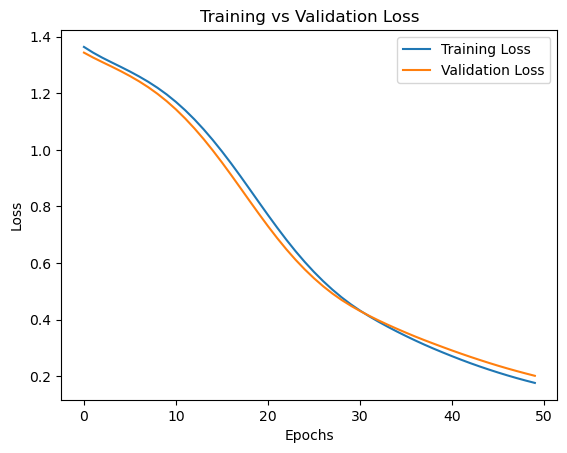

In [18]:
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [19]:
model.eval()
with torch.no_grad():
    preds = torch.argmax(model(X_val), dim=1)

acc = accuracy_score(y_val, preds)
f1 = f1_score(y_val, preds, average="weighted")

print("Accuracy:", acc)
print("F1 Score:", f1)


Accuracy: 0.9180327868852459
F1 Score: 0.9159270562190576


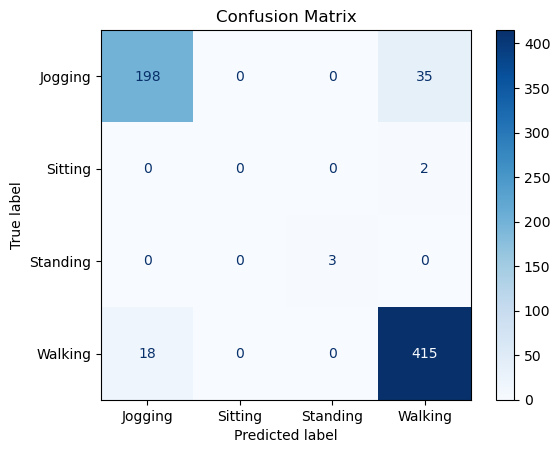

In [20]:
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
